LOGISTIC REGRESSION

# 1. Problem Framing

Predict whether a student will Pass or Fail based on study hours.

- Input (X): Study Hours
- Output (Y): Pass / Fail
- 0 = Fail
- 1 = Pass
- Type: Supervised Learning → Classification → Binary Classification

# 2. Data Collection

For this classroom example, we create a small dataset manually.

In [1]:
# Import NumPy for creating the dataset
import numpy as np

# Input data: Study Hours
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])

# Output data: 0 = Fail, 1 = Pass
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# Display the input and output data
X, y

(array([[ 1],
        [ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10]]),
 array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1]))

# 3. Data Pre-processing

The dataset is already clean. Check shape, missing values, and classes.

In [2]:
# Display the shape of the input data
print("X shape:", X.shape)

# Display the shape of the output data
print("y shape:", y.shape)

# Check for missing values in the input data
print("Missing values in X:", np.isnan(X).sum())

# Check for missing values in the output data
print("Missing values in y:", np.isnan(y).sum())

# Display the unique classes in the target variable
print("Classes:", np.unique(y))

X shape: (10, 1)
y shape: (10,)
Missing values in X: 0
Missing values in y: 0
Classes: [0 1]


# 4. Train-Test Split

Training data learns the relationship. Testing data checks performance on unseen data.
We use stratify=y so both sets contain both classes.

In [3]:
# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# test_size=0.2 → 20% data for testing
# random_state=42 → keeps the split reproducible
# stratify=y → keeps the class distribution balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display the training input values
print("X_train:", X_train.ravel())

# Display the testing input values
print("X_test:", X_test.ravel())

# Display the training target values
print("y_train:", y_train)

# Display the testing target values
print("y_test:", y_test)

X_train: [ 6  4  2  8 10  9  5  1]
X_test: [3 7]
y_train: [1 0 0 1 1 1 1 0]
y_test: [0 1]


# 5. Modeling – Logistic Regression

Logistic Regression predicts a probability between 0 and 1 and then converts it into a class such as Pass or Fail.

In [4]:
# Import LogisticRegression from scikit-learn
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
model = LogisticRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Display a message confirming successful model training
print("Model trained successfully!")

Model trained successfully!


# 6. Prediction – Pass/Fail

Use the trained model to predict classes for the test data.

In [5]:
# Predict the Pass/Fail classes for the test data
y_pred = model.predict(X_test)

# Display the actual test values
print("Actual values:", y_test)

# Display the predicted Pass/Fail values
print("Predicted values:", y_pred)

Actual values: [0 1]
Predicted values: [0 1]


# 7. Prediction – Probability of Passing

predict_proba() returns two columns:

- Column 1 → probability of Fail (0)
- Column 2 → probability of Pass (1)

In [6]:
# Calculate the probability of each class for the test data
y_prob = model.predict_proba(X_test)

# Display the probabilities of Fail and Pass
print("Probability of Fail and Pass:")
print(y_prob)

Probability of Fail and Pass:
[[0.80171244 0.19828756]
 [0.05985285 0.94014715]]


## Predict a New Student

Predict the result for a student who studies for 6.5 hours.

In [7]:
# Create a new student with 6.5 study hours
new_student = np.array([[6.5]])

# Predict the Pass/Fail result for the new student
prediction = model.predict(new_student)[0]

# Get the probability of passing (column 1 represents class 1 = Pass)
probability_pass = model.predict_proba(new_student)[0][1]

# Display the student's study hours
print("Study Hours:", new_student[0][0])

# Display the probability of passing
print("Probability of Passing:", probability_pass)

# Display the predicted result based on the model
print("Predicted Result:", "Pass" if prediction == 1 else "Fail")

Study Hours: 6.5
Probability of Passing: 0.9033706119126507
Predicted Result: Pass


# 8. Evaluation – Accuracy

Accuracy tells us the percentage of predictions that are correct.

In [8]:
# Import the accuracy_score metric
from sklearn.metrics import accuracy_score

# Calculate the accuracy using actual and predicted values
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy value
print("Accuracy:", accuracy)

# Display the accuracy as a percentage
print("Accuracy (%):", accuracy * 100)


Accuracy: 1.0
Accuracy (%): 100.0


# 9. Confusion Matrix

A confusion matrix shows how the Logistic Regression model classified
the actual Fail and Pass results.

In [10]:
# Import confusion_matrix for calculating the confusion matrix
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix using actual and predicted values
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix label
print("Confusion Matrix:")

# Display the confusion matrix values
print(cm)

Confusion Matrix:
[[1 0]
 [0 1]]


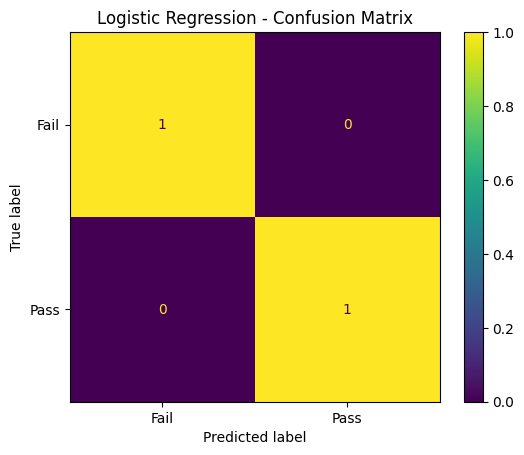

In [12]:
# Import matplotlib for displaying the confusion matrix
import matplotlib.pyplot as plt

# Import ConfusionMatrixDisplay for visualizing the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix with Fail and Pass class labels
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
).plot()

# Add a title to the confusion matrix
plt.title("Logistic Regression - Confusion Matrix")

# Display the plot
plt.show()

# 10. Evaluation – Classification Report

- Precision: Of students predicted as Pass, how many actually passed?
- Recall: Of students who actually passed, how many were correctly identified?
- F1-score: Balance between precision and recall.

In [13]:
# Import classification_report for detailed model evaluation
from sklearn.metrics import classification_report

# Generate and display the classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"],
    zero_division=0
))

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

